In [ ]:
from aleatory.processes import BrownianMotion
from aleatory.processes import GBM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
file = r'portfolios-returns.csv' 
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [ ]:
log_returns = np.log(1 + data)

In [ ]:
log_returns.iloc[:, 0]

CFD   -0.011419
OB    -0.039902
PP     0.002883
Name: 2021-10-08 00:00:00+00:00, dtype: float64

In [ ]:
mu = log_returns.mean() # daily mean return
sigma = log_returns.std() # daily standard deviation

In [ ]:
mu

CFD    0.001063
OB     0.000961
PP     0.000350
dtype: float64

In [ ]:
sigma

CFD    0.062443
OB     0.027673
PP     0.028681
dtype: float64

# **Brownian to CFDs**

In [ ]:
brownian = GBM(drift=mu.iloc[0], volatility=sigma.iloc[0], initial=1, T=30)

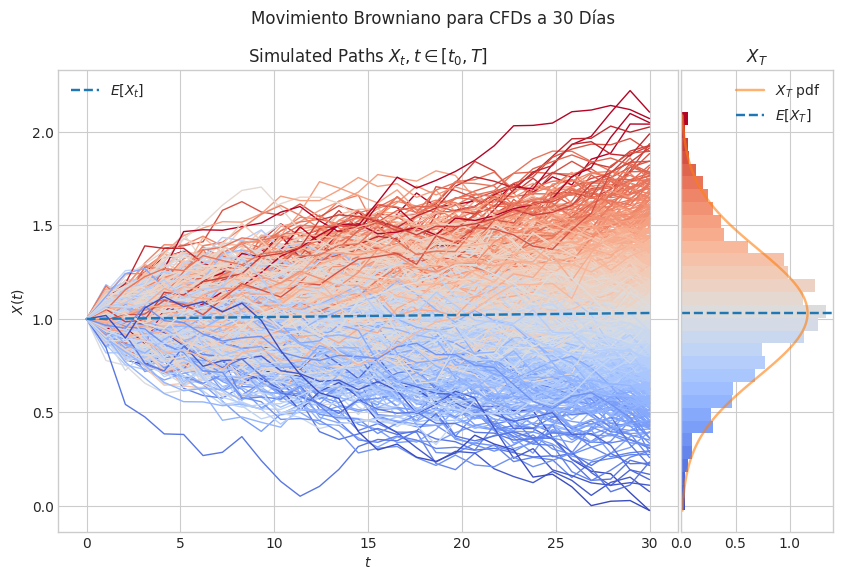

In [52]:
fig = brownian.draw(n=30, N=1000, colormap='coolwarm', envelope=False, marginal=True, title='Movimiento Browniano para CFDs a 30 Días', figsize=(10, 6))

In [53]:
# Assuming the subtitle is in the first Axes object
ax = fig.axes[0]
ax.set_title('Caminos Simulados', loc='center', fontsize=12)

# change the range of the y-axis
ax.set_ylim(0, 2)


fig.canvas.draw_idle()  # Update the figure

In [54]:
fig.savefig('svg/07-brownian-cfd.svg', format='svg', bbox_inches='tight')

# **Brownian Only Buy**

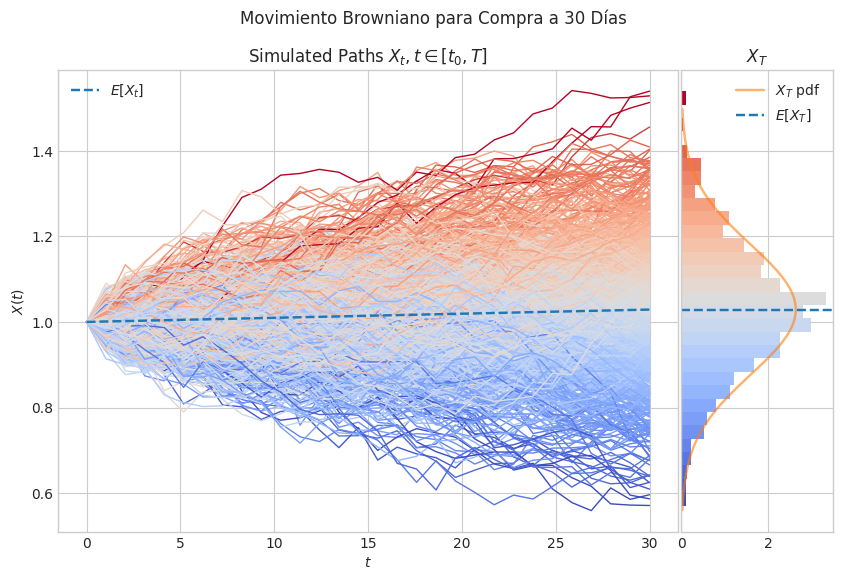

In [ ]:
brownian = BrownianMotion(drift=mu.iloc[1], volatility=sigma.iloc[1], initial=1, T=30)

fig = brownian.draw(n=30, N=1000, colormap='coolwarm', envelope=False, marginal=True, title='Movimiento Browniano Geométrico para Compra a 30 Días', figsize=(10, 6))

# Assuming the subtitle is in the first Axes object
ax = fig.axes[0]
ax.set_title('Caminos Simulados', loc='center', fontsize=12)

# change the range of the y-axis
ax.set_ylim(0, 2)

fig.canvas.draw_idle()  # Update the figure

fig.savefig('svg/07-brownian-compra.svg', format='svg', bbox_inches='tight')

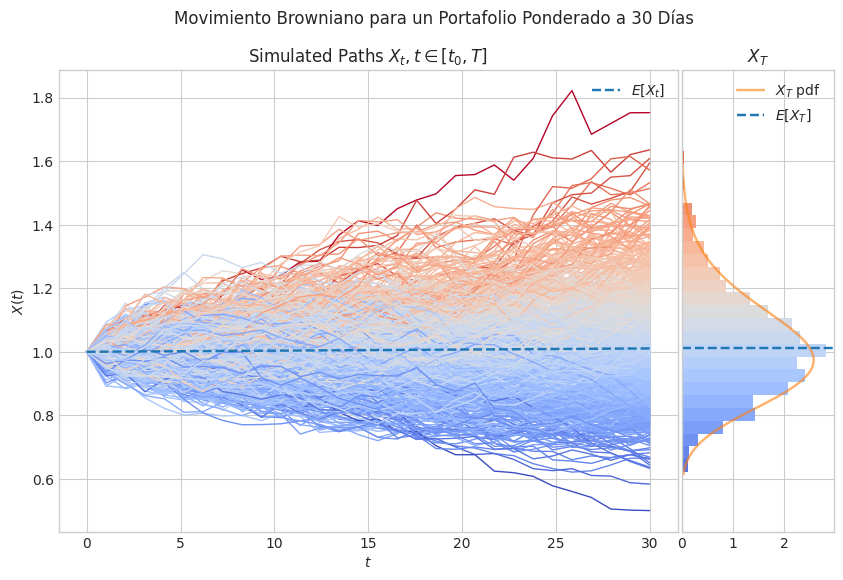

In [65]:
brownian = GBM(drift=mu.iloc[2], volatility=sigma.iloc[2], initial=1, T=30)

fig = brownian.draw(n=30, N=1000, colormap='coolwarm', envelope=False, marginal=True, title='Movimiento Browniano para un Portafolio Ponderado a 30 Días', figsize=(10, 6), alpha=0.5)

# Assuming the subtitle is in the first Axes object
ax = fig.axes[0]
ax.set_title('Caminos Simulados', loc='center', fontsize=12)

# change the range of the y-axis
ax.set_ylim(0, 2)

fig.canvas.draw_idle()  # Update the figure

fig.savefig('svg/07-Gbrownian-poderated.svg', format='svg', bbox_inches='tight')

In [60]:
brownian.process_expectation()

array([1.        , 1.00036222, 1.00072443, 1.00108665, 1.00144886,
       1.00181108, 1.00217329, 1.00253551, 1.00289772, 1.00325994,
       1.00362215, 1.00398437, 1.00434658, 1.0047088 , 1.00507101,
       1.00543323, 1.00579544, 1.00615766, 1.00651987, 1.00688209,
       1.0072443 , 1.00760652, 1.00796873, 1.00833095, 1.00869316,
       1.00905538, 1.00941759, 1.00977981, 1.01014202, 1.01050424])